Successfully loaded 803_2_PD_REST.mat | Shape: (67, 208501)
Successfully loaded 818_2_PD_REST.mat | Shape: (67, 153001)


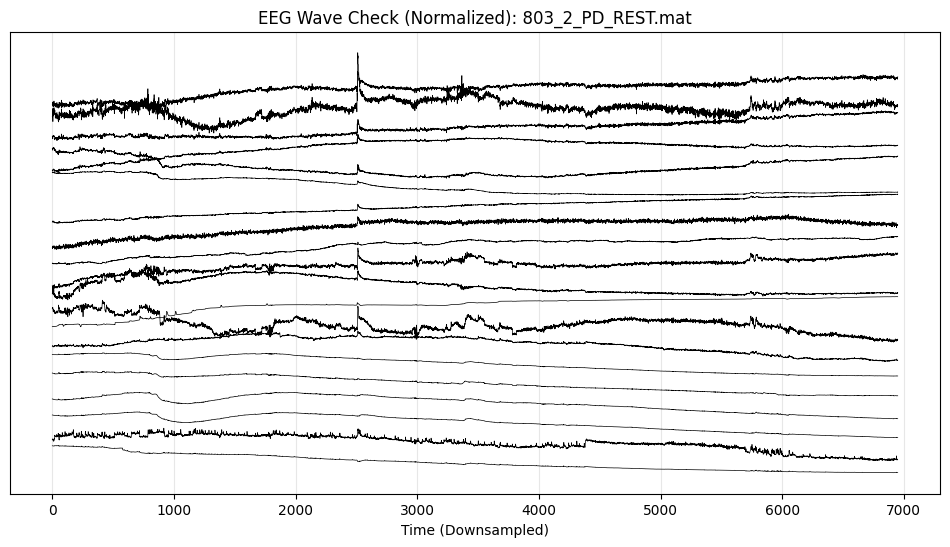

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import mat73
import scipy.io

def extract_eeg_info(eeg_struct):
    """Extract EEG data fields into a dictionary."""
    return {
        'subject': eeg_struct.get('subject', 'Unknown'),
        'group': eeg_struct.get('group', 'Unknown'),
        'condition': eeg_struct.get('condition', 'Unknown'),
        'nbchan': int(eeg_struct.get('nbchan', 0)),
        'trials': int(eeg_struct.get('trials', 0)),
        'pnts': int(eeg_struct.get('pnts', 0)),
        'srate': float(eeg_struct.get('srate', 0)),
        'data': eeg_struct.get('data'),
        'data_shape': eeg_struct['data'].shape if 'data' in eeg_struct else (0,0),
        'times': eeg_struct.get('times')
    }

def analyze_eeg_data(file_path):
    try:
        try:
            data = mat73.loadmat(file_path)
        except:
            data = scipy.io.loadmat(file_path)
            
        if 'EEG' in data:
            eeg_content = data['EEG']
            if hasattr(eeg_content, 'dtype') and eeg_content.shape == (1, 1):
                eeg_content = eeg_content[0, 0]
                eeg_content = {name: eeg_content[name] for name in eeg_content.dtype.names}
            return extract_eeg_info(eeg_content)
    except Exception as e:
        print(f"Failed to load {os.path.basename(file_path)}: {e}")
    return None

def plot_eeg_signal(eeg_info, subject_name, num_channels=20):
    """Plot channels with auto-scaling to prevent flat-line effect."""
    data = eeg_info['data']
    if data is None: return

    if len(data.shape) == 3: data = data[0, :, :]
        
    # Downsample for speed
    step = 30
    plot_data = data[:num_channels, ::step]
    
    plt.figure(figsize=(12, 6))
    
    # Auto-scale: Normalize each channel so waves are visible
    for i in range(min(num_channels, plot_data.shape[0])):
        ch_data = plot_data[i]
        # Normalize: (data - mean) / std dev makes waves visible
        std_val = np.nanstd(ch_data)
        normalized = (ch_data - np.nanmean(ch_data)) / (std_val if std_val > 0 else 1)
        plt.plot(normalized + (i * 2.5), color='black', linewidth=0.5)
        
    plt.title(f"EEG Wave Check (Normalized): {subject_name}")
    plt.xlabel("Time (Downsampled)")
    plt.yticks([])
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

def main():
    current_dir = os.path.join(os.getcwd(), 'PD_REST')
    mat_files = [f for f in os.listdir(current_dir) if f.endswith('.mat') and not f.endswith('1.mat')]
    
    # Pick 4 random subjects
    selected_files = ['803_2_PD_REST.mat', '818_2_PD_REST.mat']
    
    plot_data = None
    plot_subject = None

    for file in selected_files:
        eeg_info = analyze_eeg_data(os.path.join(current_dir, file))
        
        # FIX: Check for NoneType before accessing
        if eeg_info and eeg_info['data'] is not None and eeg_info['data'].size > 0:
            print(f"Successfully loaded {file} | Shape: {eeg_info['data_shape']}")
            if plot_data is None:
                plot_data, plot_subject = eeg_info, file
        else:
            print(f"Skipping {file}: No valid data found.")

    if plot_data:
        plot_eeg_signal(plot_data, plot_subject)

if __name__ == "__main__":
    main()


Analyzing: 803_2_PD_REST.mat
Raw shape: (67, 208501)

Original shape: (67, 208501)
Final shape: (67, 208501)

DEBUG CHECK
Shape after preprocess: (67, 208501)
Channels identical? False


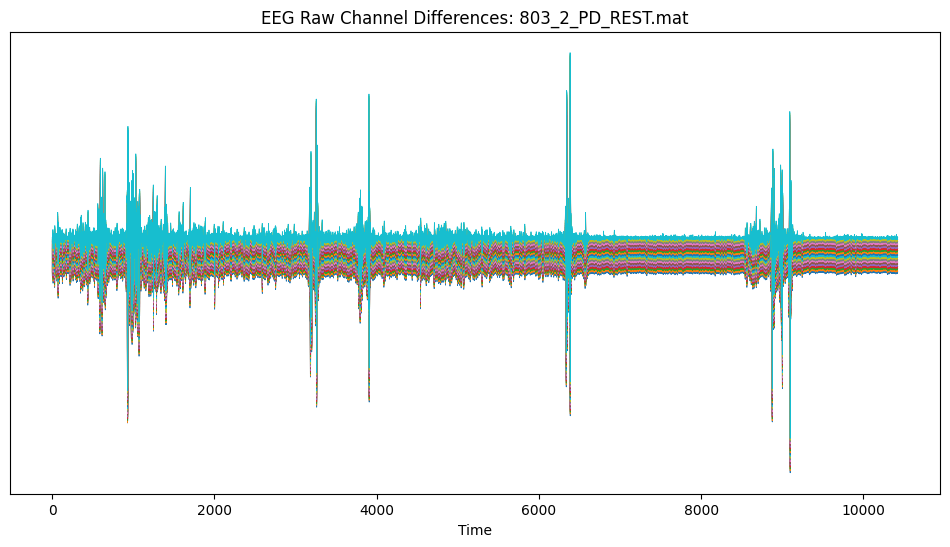


Original shape: (67, 208501)
Final shape: (67, 208501)

DEBUG CHECK
Shape after preprocess: (67, 208501)
Channels identical? False

Using channels:
Frontal index: 0
Occipital index: 66


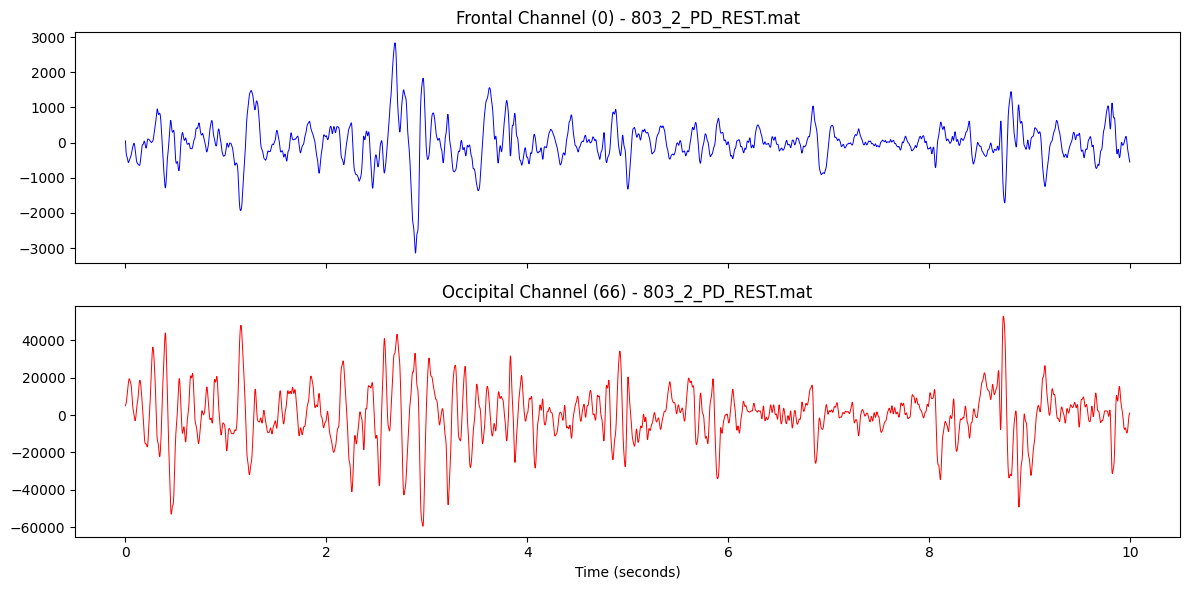


Original shape: (67, 208501)
Final shape: (67, 208501)

DEBUG CHECK
Shape after preprocess: (67, 208501)
Channels identical? False


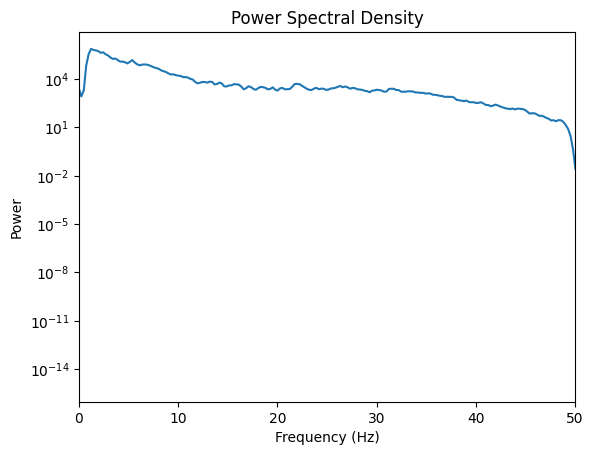


Analyzing: 818_2_PD_REST.mat
Raw shape: (67, 153001)

Original shape: (67, 153001)
Final shape: (67, 153001)

DEBUG CHECK
Shape after preprocess: (67, 153001)
Channels identical? False


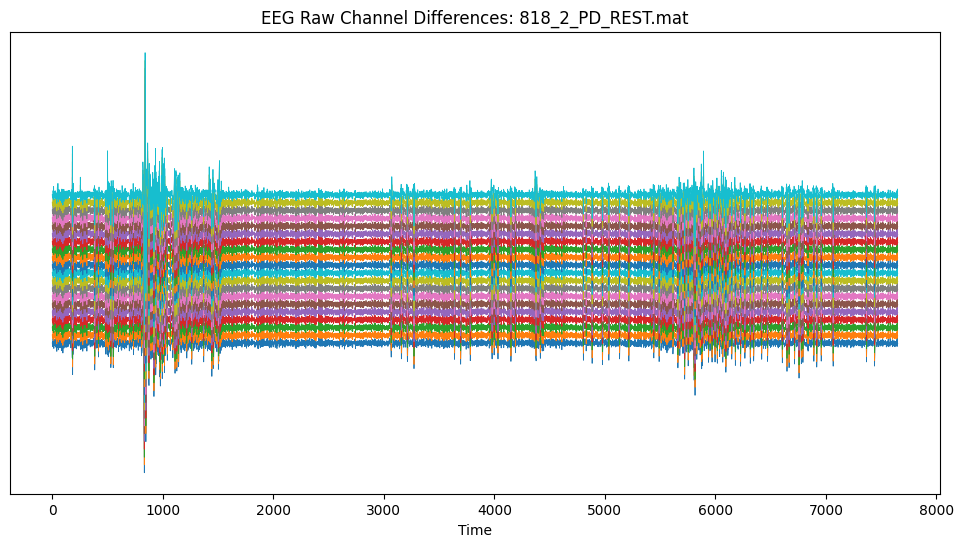


Original shape: (67, 153001)
Final shape: (67, 153001)

DEBUG CHECK
Shape after preprocess: (67, 153001)
Channels identical? False

Using channels:
Frontal index: 0
Occipital index: 66


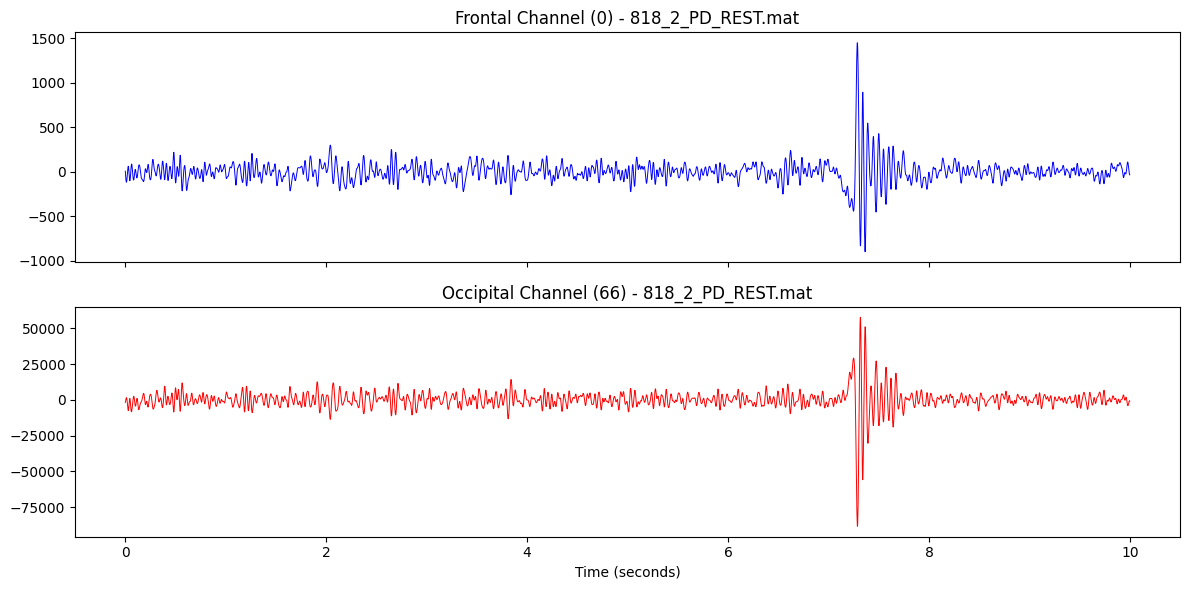


Original shape: (67, 153001)
Final shape: (67, 153001)

DEBUG CHECK
Shape after preprocess: (67, 153001)
Channels identical? False


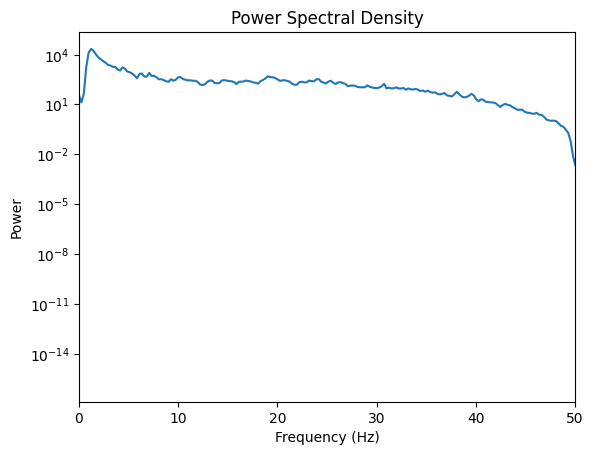

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mat73
import scipy.io
from scipy.signal import butter, filtfilt, iirnotch, welch


class PDBrainProcessor:

    def __init__(self, srate):

        # Convert MATLAB scalar safely
        self.srate = float(np.squeeze(srate))

        self.bands = {
            'Delta': (0.5, 4),
            'Theta': (4, 8),
            'Alpha': (8, 13),
            'Beta (Motor)': (13, 30),
            'Tremor': (3, 6)
        }

    # --------------------------------------------------
    # ORIENTATION FIX
    # --------------------------------------------------

    def ensure_channel_first(self, data):
        """
        Ensures EEG shape is (channels, time)
        """

        print("\nOriginal shape:", data.shape)

        # If time dimension is first → transpose
        if data.shape[0] > data.shape[1]:
            print("Transposing to (channels, time)")
            data = data.T

        print("Final shape:", data.shape)

        return data

    # --------------------------------------------------
    # FILTERING
    # --------------------------------------------------

    def apply_bandpass(self, data, low=1.0, high=40.0):

        nyq = 0.5 * self.srate

        b, a = butter(
            4,
            [low / nyq, high / nyq],
            btype='band'
        )

        return filtfilt(b, a, data, axis=-1)

    def apply_notch(self, data, freq=50.0):

        nyq = 0.5 * self.srate

        b, a = iirnotch(freq / nyq, 35)

        return filtfilt(b, a, data, axis=-1)

    def apply_avg_ref(self, data):
        """
        Average reference across channels
        """

        if data.ndim == 2:
            return data - np.mean(
                data,
                axis=0,
                keepdims=True
            )

        if data.ndim == 3:
            return data - np.mean(
                data,
                axis=1,
                keepdims=True
            )

        return data

    # --------------------------------------------------
    # MASTER PREPROCESSING PIPELINE
    # --------------------------------------------------

    def preprocess(self, raw_data):

        data = np.squeeze(raw_data)

        # Fix orientation
        data = self.ensure_channel_first(data)

        # Correct order
        data = self.apply_bandpass(data)
        data = self.apply_notch(data)
        data = self.apply_avg_ref(data)

        # Debug check
        print("\nDEBUG CHECK")
        print("Shape after preprocess:", data.shape)

        if data.shape[0] > 1:
            print(
                "Channels identical?",
                np.allclose(data[0], data[1])
            )

        return data

    # --------------------------------------------------
    # MULTI-CHANNEL WAVE PLOT
    # --------------------------------------------------

    def plot_eeg_signal_filtered(
            self,
            raw_data,
            subject_name,
            num_channels=20):

        data = self.preprocess(raw_data)

        step = 20

        plot_data = data[:num_channels, ::step]

        plt.figure(figsize=(12, 6))

        spacing = 200  # vertical spacing

        for i in range(plot_data.shape[0]):

            ch_data = plot_data[i]

            plt.plot(
                ch_data + i * spacing,
                linewidth=0.6
            )

        plt.title(
            f"EEG Raw Channel Differences: {subject_name}"
        )

        plt.xlabel("Time")

        plt.yticks([])

        plt.show()
        
    # --------------------------------------------------
    # FRONTAL vs OCCIPITAL
    # --------------------------------------------------

    def plot_comparison(
        self,
        raw_data,
        subject,
        chan_labels=None):

        data = self.preprocess(raw_data)

        # --------------------------------
        # Find frontal & occipital indices
        # --------------------------------

        if chan_labels is not None:

            frontal_names = ['Fp1', 'Fp2', 'F3', 'F4']
            occipital_names = ['O1', 'O2', 'Oz']

            front_idx = None
            back_idx = None

            for i, label in enumerate(chan_labels):

                if label in frontal_names and front_idx is None:
                    front_idx = i

                if label in occipital_names and back_idx is None:
                    back_idx = i

            # fallback if not found
            if front_idx is None:
                front_idx = 0

            if back_idx is None:
                back_idx = data.shape[0] - 1

        else:

            front_idx = 0
            back_idx = data.shape[0] - 1

        ch_front = data[front_idx]
        ch_back = data[back_idx]

        print(f"\nUsing channels:")
        print(f"Frontal index: {front_idx}")
        print(f"Occipital index: {back_idx}")

        # --------------------------------
        # Plot longer window (better view)
        # --------------------------------

        duration = 10  # seconds

        samples = int(duration * self.srate)

        t = np.arange(samples) / self.srate

        fig, (ax1, ax2) = plt.subplots(
            2,
            1,
            figsize=(12, 6),
            sharex=True
        )

        ax1.plot(
            t,
            ch_front[:samples],
            color='blue',
            lw=0.7
        )

        ax1.set_title(
            f"Frontal Channel ({front_idx}) - {subject}"
        )

        ax2.plot(
            t,
            ch_back[:samples],
            color='red',
            lw=0.7
        )

        ax2.set_title(
            f"Occipital Channel ({back_idx}) - {subject}"
        )

        plt.xlabel("Time (seconds)")

        plt.tight_layout()

        plt.show()

    # --------------------------------------------------
    # POWER SPECTRUM (VERY IMPORTANT)
    # --------------------------------------------------

    def plot_psd(self, raw_data):

        data = self.preprocess(raw_data)

        sig = data[0]

        f, pxx = welch(
            sig,
            fs=self.srate,
            nperseg=2048
        )

        plt.figure()

        plt.semilogy(f, pxx)

        plt.title("Power Spectral Density")

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power")

        plt.xlim(0, 50)

        plt.show()


# --------------------------------------------------
# LOAD MATLAB FILE
# --------------------------------------------------

def load_eeg(path):

    try:
        data = mat73.loadmat(path)

    except:
        data = scipy.io.loadmat(path)

    eeg = data.get('EEG', {})

    if hasattr(eeg, 'dtype'):

        eeg = {
            n: eeg[0, 0][n]
            for n in eeg.dtype.names
        }

    return eeg


# --------------------------------------------------
# MAIN
# --------------------------------------------------

def main():

    path = os.path.join(
        os.getcwd(),
        'PD_REST'
    )

    selected_files = [
        '803_2_PD_REST.mat',
        '818_2_PD_REST.mat'
    ]

    for file in selected_files:

        info = load_eeg(
            os.path.join(path, file)
        )

        if (
            info.get('data') is not None
            and
            info.get('srate') is not None
        ):

            print("\n" + "=" * 40)
            print("Analyzing:", file)
            print("=" * 40)

            print(
                "Raw shape:",
                info['data'].shape
            )

            proc = PDBrainProcessor(
                info['srate']
            )

            proc.plot_eeg_signal_filtered(
                info['data'],
                file
            )

            proc.plot_comparison(
                info['data'],
                file
            )

            proc.plot_psd(
                info['data']
            )

        else:

            print(
                f"Skipping {file}: Missing data"
            )


if __name__ == "__main__":
    main()